# Visualizing and analysing the data

## Importing the libraries

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.model_selection import cross_val_score

## Read the Dataset

In [7]:
df=pd.read_csv("emp_promotion.csv")

In [8]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [9]:
df.shape

(54808, 14)

## Univariate Analysis

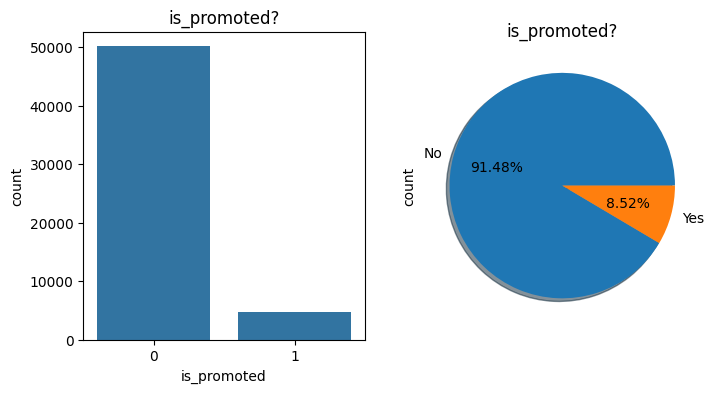

In [10]:
plt.figure(figsize=(8,4))
plt.subplot(121)
#countplot
sns.countplot(x="is_promoted",data=df)
plt.title("is_promoted?")
plt.subplot(122)
#pieplot
plt.title("is_promoted?")
val_count=df["is_promoted"].value_counts()
val_count.plot(kind="pie",autopct='%.2f%%',shadow=True,labels=["No","Yes"])
plt.show()

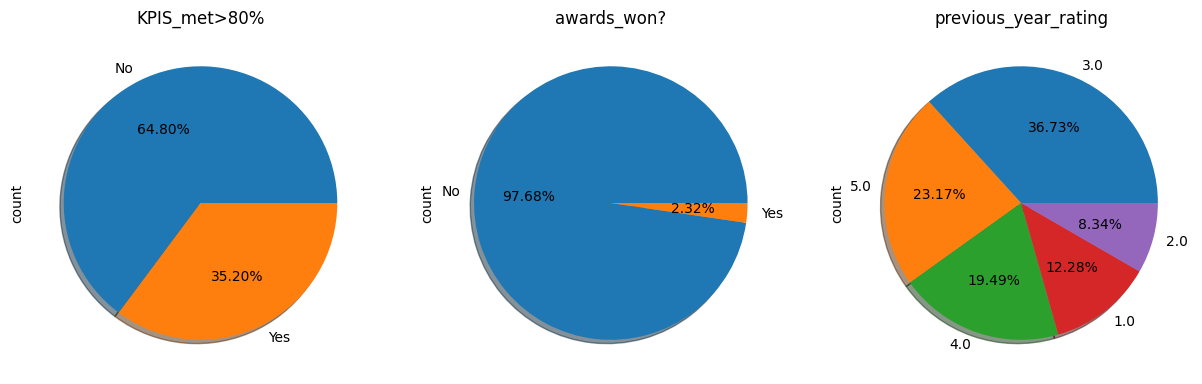

In [11]:
plt.figure(figsize=(15,15))
plt.subplot(131)
plt.title("KPIS_met>80%")
df["KPIs_met >80%"].value_counts().plot(kind="pie",shadow=True,autopct="%.2f%%",labels=["No","Yes"])
plt.subplot(132)
plt.title("awards_won?")
df["awards_won?"].value_counts().plot(kind="pie",shadow=True,autopct="%.2f%%",labels=["No","Yes"])
plt.subplot(133)
plt.title("previous_year_rating")
df["previous_year_rating"].value_counts().plot(kind="pie",shadow=True,autopct="%.2f%%")
plt.show()

<Axes: xlabel='avg_training_score'>

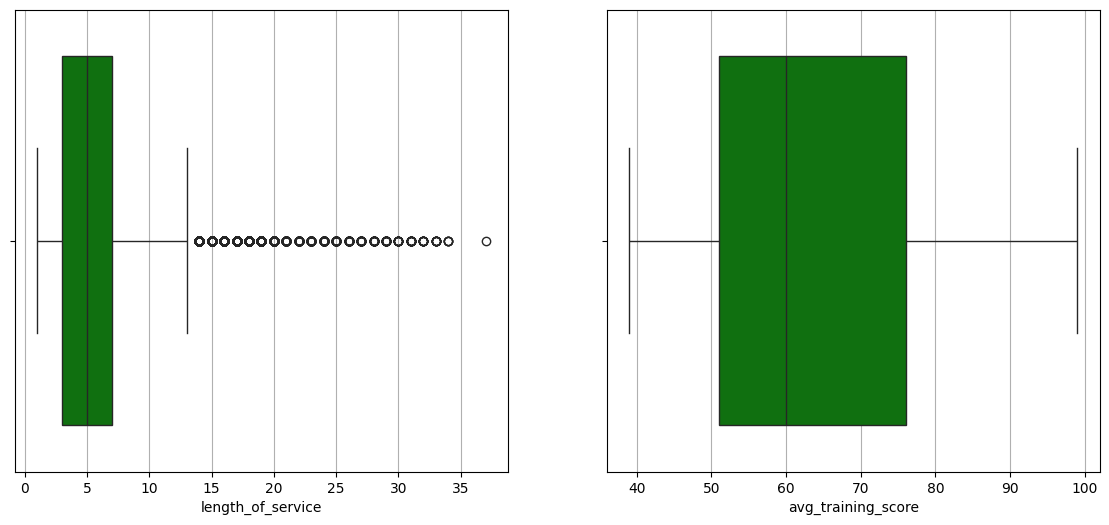

In [12]:
#boxplot
plt.figure(figsize=(14,6))
plt.subplot(121)
plt.grid()
plt.xlabel("length_of_service")
sns.boxplot(df["length_of_service"],color='g',orient="h")
plt.subplot(122)
plt.grid()
plt.xlabel("avg_training_score")
sns.boxplot(df["avg_training_score"],color='g',orient="h")

## Multivariate Analysis

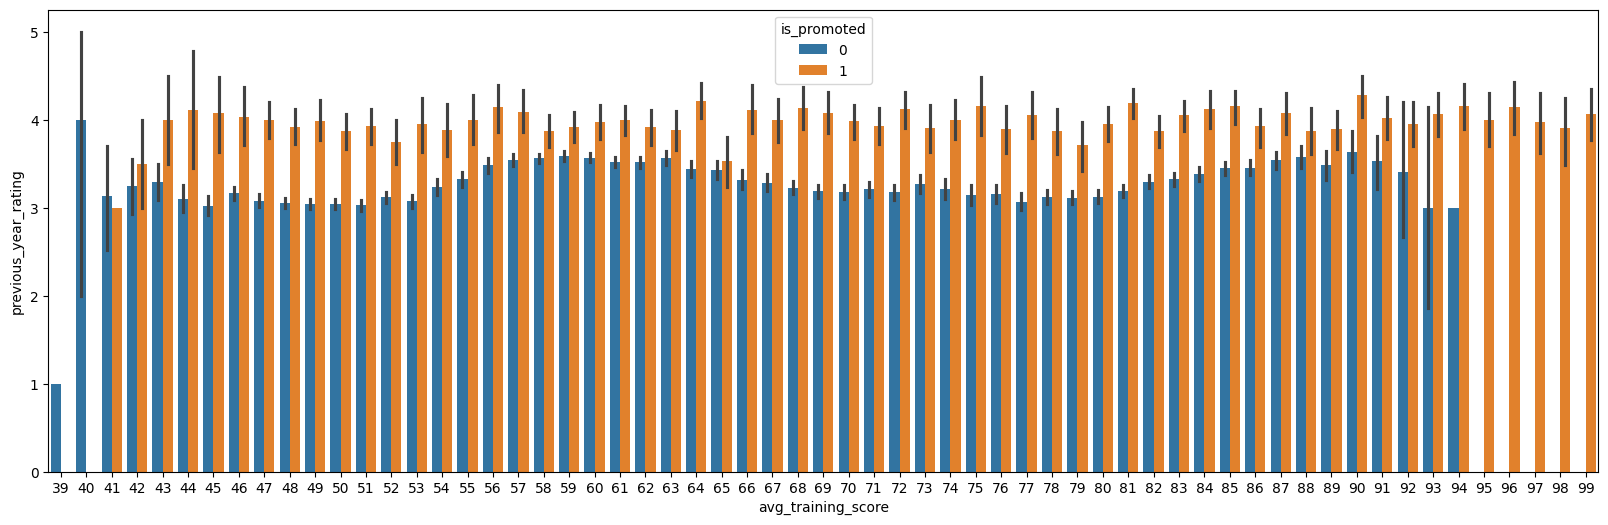

In [13]:
#barplot
plt.figure(figsize=(20,6))
df['is_promoted'] = df['is_promoted'].astype(str)
sns.barplot(x="avg_training_score",y="previous_year_rating",hue="is_promoted",data=df)
plt.show()

## Descriptive analysis

In [14]:
df.describe(include="all")

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808,54808,52399,54808,54808,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000,54808
unique,NaN,9,34,3,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,Sales & Marketing,region_2,Bachelor's,m,other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
freq,NaN,16840,12343,36669,38496,30446,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50140
mean,39195.830627,NaN,NaN,NaN,NaN,NaN,1.253011,34.803915,3.329256,5.865512,0.351974,0.023172,63.386750,NaN
std,22586.581449,NaN,NaN,NaN,NaN,NaN,0.609264,7.660169,1.259993,4.265094,0.477590,0.150450,13.371559,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000,39.000000,NaN
25%,19669.750000,NaN,NaN,NaN,NaN,NaN,1.000000,29.000000,3.000000,3.000000,0.000000,0.000000,51.000000,NaN
50%,39225.500000,NaN,NaN,NaN,NaN,NaN,1.000000,33.000000,3.000000,5.000000,0.000000,0.000000,60.000000,NaN
75%,58730.500000,NaN,NaN,NaN,NaN,NaN,1.000000,39.000000,4.000000,7.000000,1.000000,0.000000,76.000000,NaN


# Data Pre-processing

## Drop unwanted features

In [15]:
df=df.drop(["employee_id","gender","region","recruitment_channel"],axis=1)

In [16]:
df.head()

,department,education,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,Sales & Marketing,Master's & above,1,35,5.0,8,1,0,49,0
1,Operations,Bachelor's,1,30,5.0,4,0,0,60,0
2,Sales & Marketing,Bachelor's,1,34,3.0,7,0,0,50,0
3,Sales & Marketing,Bachelor's,2,39,1.0,10,0,0,50,0
4,Technology,Bachelor's,1,45,3.0,2,0,0,73,0


## Checking for null values

In [17]:
df.isnull().sum()

department                 0
education               2409
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [18]:
#handling null values
df["education"]=df["education"].fillna(df["education"].mode()[0])
df["previous_year_rating"]=df["previous_year_rating"].fillna(df["previous_year_rating"].mode()[0])


In [19]:
df.isnull().sum()

department              0
education               0
no_of_trainings         0
age                     0
previous_year_rating    0
length_of_service       0
KPIs_met >80%           0
awards_won?             0
avg_training_score      0
is_promoted             0
dtype: int64

## Remove negative data

In [20]:
negative=df[(df['KPIs_met >80%']==0)&(df["awards_won?"]==0) &(df["previous_year_rating"]==1.0) & (df["is_promoted"]==1) & (df["avg_training_score"]<60)]
negative

,department,education,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted


## Handling outliers

In [21]:
q1=np.quantile(df["length_of_service"],0.25)
q3=np.quantile(df["length_of_service"],0.75)
IQR=q3-q1
upperbound=(1.5*IQR)+q3
lowerbound=(1.5*IQR)-q1
print("q1:",q1)
print("q3:",q3)
print("IQR:",IQR)
print("Upper Bound:",upperbound)
print("Lower Bound:",lowerbound)
print("Skewed data:",len(df[df["length_of_service"]>upperbound]))

q1: 3.0
q3: 7.0
IQR: 4.0
Upper Bound: 13.0
Lower Bound: 3.0
Skewed data: 3489


In [22]:
pd.crosstab([df["length_of_service"]>upperbound],df["is_promoted"])

is_promoted,0,1
length_of_service,,
False,46885,4434
True,3255,234


In [23]:
#outliers cant be removed because employee with higher length of services has higher promotion percentage.so capping is done on this feature.
#capping
df["length_of_service"]=[upperbound if x>upperbound else x for x in df["length_of_service"]]

## Handling Categorical Values

In [24]:
df.head()

,department,education,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,Sales & Marketing,Master's & above,1,35,5.0,8.0,1,0,49,0
1,Operations,Bachelor's,1,30,5.0,4.0,0,0,60,0
2,Sales & Marketing,Bachelor's,1,34,3.0,7.0,0,0,50,0
3,Sales & Marketing,Bachelor's,2,39,1.0,10.0,0,0,50,0
4,Technology,Bachelor's,1,45,3.0,2.0,0,0,73,0


In [25]:
le=LabelEncoder()
df["department"]=le.fit_transform(df["department"])
df["education"]=le.fit_transform(df["education"])
df.head()

,department,education,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,7,2,1,35,5.0,8.0,1,0,49,0
1,4,0,1,30,5.0,4.0,0,0,60,0
2,7,0,1,34,3.0,7.0,0,0,50,0
3,7,0,2,39,1.0,10.0,0,0,50,0
4,8,0,1,45,3.0,2.0,0,0,73,0


## Handling Imbalanced data

In [26]:
#splitting data and resampling it
x=df.drop("is_promoted",axis=1)
y=df["is_promoted"]
print(x.shape)
print(y.shape)

(54808, 9)
(54808,)


In [27]:
from imblearn.over_sampling import SMOTE
sm=SMOTE()
x_resample,y_resample=sm.fit_resample(x,y)


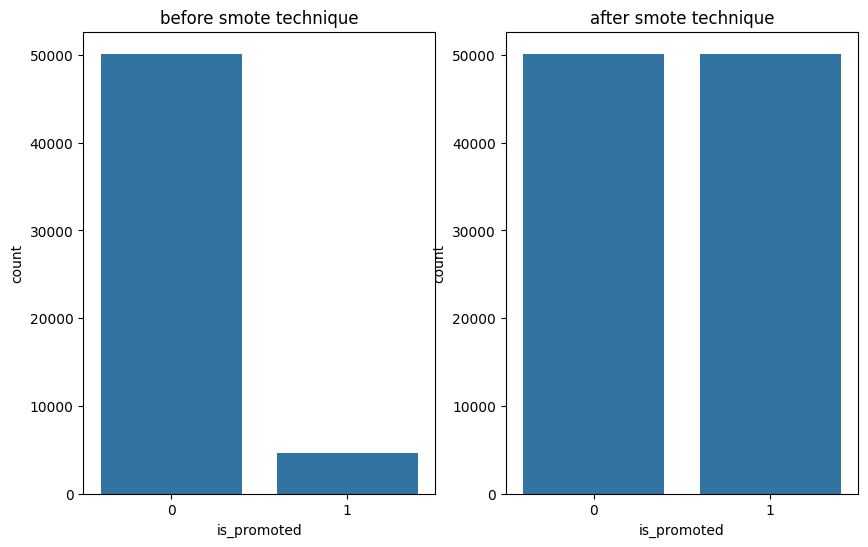

In [28]:
#visualization before and after smote technique
plt.figure(figsize=(10,6))
plt.subplot(121)
sns.countplot(x=y,data=df)
plt.title("before smote technique")
plt.subplot(122)
sns.countplot(x=y_resample,data=df)
plt.title("after smote technique")
plt.show()

In [29]:
df.head()

,department,education,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,7,2,1,35,5.0,8.0,1,0,49,0
1,4,0,1,30,5.0,4.0,0,0,60,0
2,7,0,1,34,3.0,7.0,0,0,50,0
3,7,0,2,39,1.0,10.0,0,0,50,0
4,8,0,1,45,3.0,2.0,0,0,73,0


## Standardization

In [30]:
from sklearn.preprocessing import MinMaxScaler
scale=MinMaxScaler()
x_resample=scale.fit_transform(x_resample)
x_resample

array([[0.875     , 1.        , 0.        , ..., 1.        , 0.        ,
        0.16666667],
       [0.5       , 0.        , 0.        , ..., 0.        , 0.        ,
        0.35      ],
       [0.875     , 0.        , 0.        , ..., 0.        , 0.        ,
        0.18333333],
       ...,
       [0.875     , 1.        , 0.        , ..., 1.        , 0.        ,
        0.18333333],
       [0.5       , 0.        , 0.        , ..., 1.        , 0.        ,
        0.33333333],
       [0.875     , 0.        , 0.11111111, ..., 0.        , 0.        ,
        0.38333333]])

In [31]:
df.head()

,department,education,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,7,2,1,35,5.0,8.0,1,0,49,0
1,4,0,1,30,5.0,4.0,0,0,60,0
2,7,0,1,34,3.0,7.0,0,0,50,0
3,7,0,2,39,1.0,10.0,0,0,50,0
4,8,0,1,45,3.0,2.0,0,0,73,0


## Splitting data into train and test

In [32]:
x_train,x_test,y_train,y_test=train_test_split(x_resample,y_resample,test_size=0.2,random_state=0)

# Model Building

## Decision Tree Model

In [33]:
def DecisionTree(x_train,x_test,y_train,y_test):
    det=DecisionTreeClassifier()
    det.fit(x_train,y_train)
    y_pred=det.predict(x_test)
    print("***DecisionTreeClassifier***")
    print("confusion matrix")
    print(confusion_matrix(y_test,y_pred))
    print("classification report")
    print(classification_report(y_test,y_pred))

## Decision Tree - Hyper Parameter Tuning

In [34]:
# from sklearn.model_selection import GridSearchCV
# param_grid = {
#     'max_depth': [10, 20, 30, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }
# grid_search=GridSearchCV(DecisionTreeClassifier(),param_grid=param_grid)
# grid_search.fit(x_train,y_train)
# print(grid_search.best_params_) 

In [35]:
# def DecisionTree_tuned(x_train,x_test,y_train,y_test):
#     dt=DecisionTreeClassifier(max_depth= None, min_samples_leaf= 1, min_samples_split= 5)
#     dt.fit(x_train,y_train)
#     y_pred=dt.predict(x_test)
#     print("***DecisionTreeClassifier_tuned***")
#     print("confusion matrix")
#     print(confusion_matrix(y_test,y_pred))
#     print("classification report")
#     print(classification_report(y_test,y_pred))
    

## Random Forest Model

In [36]:
def RandomForest(x_train,x_test,y_train,y_test):
    rf=RandomForestClassifier()
    rf.fit(x_train,y_train)
    y_pred=rf.predict(x_test)
    print("***RandomForestClassifier***")
    print("confusion matrix")
    print(confusion_matrix(y_test,y_pred))
    print("classification report")
    print(classification_report(y_test,y_pred))

## Random Forest - hyper parameter tuning

In [37]:
# from sklearn.model_selection import RandomizedSearchCV
# parameters = { 
# 	'n_estimators': [25, 50, 100, 150], 
# 	'max_features': ['sqrt', 'log2', None], 
# 	'max_depth': [3, 6, 9], 
# 	'max_leaf_nodes': [3, 6, 9], 
# } 
# rcv = RandomizedSearchCV(RandomForestClassifier(), 
# 						param_distributions=parameters) 
# rcv.fit(x_train, y_train) 
# print(rcv.best_params_) 


In [38]:
# def RandomForest_tuned(x_train,x_test,y_train,y_test):
#     rf=RandomForestClassifier(n_estimators=25,max_leaf_nodes=9,max_features='sqrt',max_depth=9)
#     rf.fit(x_train,y_train)
#     y_pred=rf.predict(x_test)
#     print("***RandomForestClassifier_tuned***")
#     print("confusion matrix")
#     print(confusion_matrix(y_test,y_pred))
#     print("classification report")
#     print(classification_report(y_test,y_pred))

## KNN Model

In [39]:
def KNN(x_train,x_test,y_train,y_test):
    knn=KNeighborsClassifier()
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    print("***KNeighborsClassifier***")
    print("confusion matrix")
    print(confusion_matrix(y_test,y_pred))
    print("classification report")
    print(classification_report(y_test,y_pred))

## KNN Model - Hyper parameter Tuning

In [40]:
# param_grid = {'n_neighbors': [5,10],
#               'weights': ['uniform', 'distance'],
#               'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
#               'p': [1, 2]}
# grid_s=GridSearchCV(KNeighborsClassifier(),param_grid)
# grid_s.fit(x_train,y_train)
# print(grid_s.best_params_)

In [41]:
# def KNN_tuned(x_train,x_test,y_train,y_test):
#     knn=KNeighborsClassifier(algorithm="ball_tree", n_neighbors= 5, p= 1, weights= "distance")
#     knn.fit(x_train,y_train)
#     y_pred=knn.predict(x_test)
#     print("***KNeighborsClassifier_tuned***")
#     print("confusion matrix")
#     print(confusion_matrix(y_test,y_pred))
#     print("classification report")
#     print(classification_report(y_test,y_pred))

## GradientBoosting Model

In [42]:
def gboost(x_train,x_test,y_train,y_test):
    g=GradientBoostingClassifier()
    g.fit(x_train,y_train)
    y_pred=g.predict(x_test)
    print("***GradientBoostingClassifier***")
    print("confusion matrix")
    print(confusion_matrix(y_test,y_pred))
    print("classification report")
    print(classification_report(y_test,y_pred))

## GradientBoosting Model - Hyper Parameter Tuning

In [43]:
# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'max_depth': [3, 5, 7],
# }
# grid_search = GridSearchCV(estimator=GradientBoostingClassifier(), param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
# grid_search.fit(x_train, y_train)
# print(grid_search.best_params_)

In [44]:
# def gboost_tuned(x_train,x_test,y_train,y_test):
#     g=GradientBoostingClassifier(learning_rate= 0.2, max_depth= 7, n_estimators= 200)
#     g.fit(x_train,y_train)
#     y_pred=g.predict(x_test)
#     print("***GradientBoostingClassifier_tuned***")
#     print("confusion matrix")
#     print(confusion_matrix(y_test,y_pred))
#     print("classification report")
#     print(classification_report(y_test,y_pred))

## XGboost model

In [45]:
import xgboost as xgb
def xgboost(x_train,x_test,y_train,y_test):
    y_train = y_train.astype(int)
    y_test = y_test.astype(int)
    xx=xgb.XGBClassifier()
    xx.fit(x_train,y_train)
    y_pred=xx.predict(x_test)
    print("***XgBoostingClassifier***")
    print("confusion matrix")
    print(confusion_matrix(y_test,y_pred))
    print("classification report")
    print(classification_report(y_test,y_pred))

## XGboost - Hyper Parameter Tuning

In [46]:
# param_grid = {
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.1, 0.01, 0.001],
#     'subsample': [0.5, 0.7, 1]
# }
# y_train = y_train.astype(int)
# grid_search = GridSearchCV(xgb.XGBClassifier(), param_grid, cv=5, scoring='accuracy')
# grid_search.fit(x_train, y_train)
# print(grid_search.best_params_)

In [47]:
# def xgboost_tuned(x_train,x_test,y_train,y_test):
#     y_train = y_train.astype(int)
#     y_test = y_test.astype(int)
#     xx=xgb.XGBClassifier(learning_rate= 0.1, max_depth= 7, subsample= 0.7)
#     xx.fit(x_train,y_train)
#     y_pred=xx.predict(x_test)
#     print("***XgBoostingClassifier_tuned***")
#     print("confusion matrix")
#     print(confusion_matrix(y_test,y_pred))
#     print("classification report")
#     print(classification_report(y_test,y_pred))

In [48]:
def CompareModels(x_train,x_test,y_train,y_test):
    y_train = y_train.astype(int)
    y_test = y_test.astype(int)
    DecisionTree(x_train,x_test,y_train,y_test)
    print("-"*100)
    # DecisionTree_tuned(x_train,x_test,y_train,y_test)
    # print("-"*100)
    RandomForest(x_train,x_test,y_train,y_test)
    print("-"*100)
    # RandomForest_tuned(x_train,x_test,y_train,y_test)
    # print("-"*100)
    KNN(x_train,x_test,y_train,y_test)
    print("-"*100)
    # KNN_tuned(x_train,x_test,y_train,y_test)
    # print("-"*100)
    gboost(x_train,x_test,y_train,y_test)
    print("-"*100)
    # gboost_tuned(x_train,x_test,y_train,y_test)
    # print("-"*100)
    xgboost(x_train,x_test,y_train,y_test)
    print("-"*100)
    # xgboost_tuned(x_train,x_test,y_train,y_test)
    # print("-"*100)
    

In [49]:
CompareModels(x_train,x_test,y_train,y_test)

***DecisionTreeClassifier***
confusion matrix
[[9206  775]
 [ 561 9514]]
classification report
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      9981
           1       0.92      0.94      0.93     10075

    accuracy                           0.93     20056
   macro avg       0.93      0.93      0.93     20056
weighted avg       0.93      0.93      0.93     20056

----------------------------------------------------------------------------------------------------
***RandomForestClassifier***
confusion matrix
[[9430  551]
 [ 472 9603]]
classification report
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      9981
           1       0.95      0.95      0.95     10075

    accuracy                           0.95     20056
   macro avg       0.95      0.95      0.95     20056
weighted avg       0.95      0.95      0.95     20056

-------------------------------------------------------

## Other Classification Algorithms

In [50]:
#logistic regression
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
y_train = y_train.astype(int)
y_test = y_test.astype(int)
lr.fit(x_train,y_train)
y_p=lr.predict(x_test)
accuracy_score( y_test,y_p)

0.7031312325488632

In [51]:
#naive bayes
from sklearn.naive_bayes import GaussianNB
nb=GaussianNB()
nb.fit(x_train,y_train)
pred=nb.predict(x_test)
accuracy_score( y_test,pred)

0.7179896290386917

## Evaluating performance of the model and saving the model

In [52]:
#random forest is selected
rf=RandomForestClassifier()
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
cv=cross_val_score(rf,x_resample,y_resample,cv=10)
np.mean(cv)

0.9500997207818109

In [56]:
import pickle
pickle.dump(rf,open("promotion-prediction.pkl","wb"))
pickle.dump(le,open("encoding.pkl","wb"))
pickle.dump(scale,open("scaling.pkl","wb"))